In [25]:
#preprocessing dataset in dataset.csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
df=pd.read_csv('dataset.csv')

In [27]:
print(df.shape)
print(df.head())

(102000, 12)
   user_id  trip_frequency  average_booking_value  destination_diversity  \
0        1             2.0             477.916475                    3.0   
1        2             4.0             745.386106                    1.0   
2        3             2.0             307.515034                    8.0   
3        4            10.0             242.283113                    3.0   
4        5             2.0             663.808316                    7.0   

   session_duration     search_behavior  loyalty_score  discount_usage_rate  \
0          6.139695        raresearcher      92.386728             0.308606   
1         40.870961    frequentsearcher       6.028547             0.935137   
2          4.412671        raresearcher       5.511370             0.019389   
3         12.822574  occasionalsearcher      72.440151             0.003189   
4         47.873046    frequentsearcher      86.819610             0.038843   

   booking_lead_time  cancellation_rate  weekend_travel

In [28]:
#identifying numeric columns
numericols=df.select_dtypes(include=np.number).columns.tolist()
print(numericols)

['user_id', 'trip_frequency', 'average_booking_value', 'destination_diversity', 'session_duration', 'loyalty_score', 'discount_usage_rate', 'booking_lead_time', 'cancellation_rate', 'weekend_travel_ratio', 'app_engagement_score']


In [29]:
#identifying categorical columns
categoricalcols=df.select_dtypes(include=object).columns.tolist()
print(categoricalcols)

['search_behavior']


C:\Users\vansh\AppData\Local\Temp\ipykernel_50712\2004515858.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricalcols=df.select_dtypes(include=object).columns.tolist()


In [30]:
#handling missing values
# For Numeric Columns
for col in numericols:
    df[col] = df[col].fillna(df[col].mean())

# For Categorical Columns
for col in categoricalcols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [31]:
#removing duplicate rows
df.drop_duplicates(inplace=True)

In [32]:
#outlier handling
for col in numericols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lowerbound=Q1-1.5*IQR
    upperbound=Q3+1.5*IQR
    df[col]=np.where(df[col]<lowerbound,lowerbound,np.where(df[col]>upperbound,upperbound,df[col]))

In [33]:
# hot encoding of categorical variables
for col in categoricalcols:
    df[col]=df[col].astype('category')
    df[col]=df[col].cat.codes
    print(df.head())

   user_id  trip_frequency  average_booking_value  destination_diversity  \
0      1.0             2.0             477.916475                    3.0   
1      2.0             4.0             745.386106                    1.0   
2      3.0             2.0             307.515034                    8.0   
3      4.0            10.0             242.283113                    3.0   
4      5.0             2.0             663.808316                    7.0   

   session_duration  search_behavior  loyalty_score  discount_usage_rate  \
0          6.139695                2      92.386728             0.308606   
1         40.870961                0       6.028547             0.935137   
2          4.412671                2       5.511370             0.019389   
3         12.822574                1      72.440151             0.003189   
4         47.873046                0      86.819610             0.038843   

   booking_lead_time  cancellation_rate  weekend_travel_ratio  \
0          14.482361 

In [34]:
#feature selection or column dropping
#dropping userid
df.drop('user_id',axis=1,inplace=True)


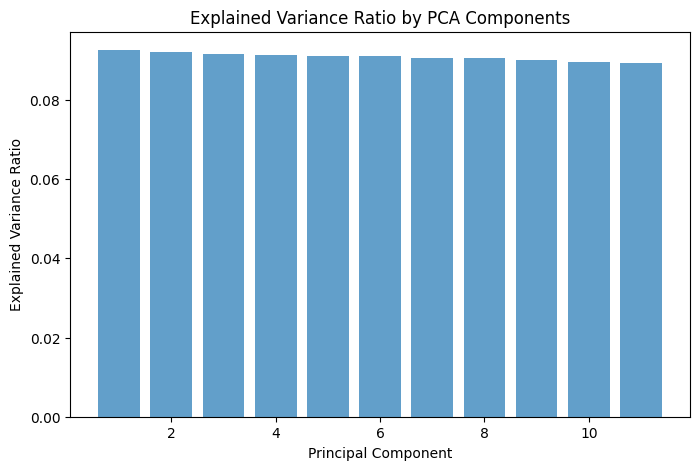

Final clustering dataset saved successfully with only required features.


In [35]:
# Feature scaling and PCA demonstration
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standard scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_features, columns=df.columns)

# PCA for analysis only (do not use PCA columns in final output)
pca = PCA(n_components=None)
pca_features = pca.fit_transform(scaled_df)
explained_var = pca.explained_variance_ratio_

# Visualize explained variance ratio
plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by PCA Components')
plt.show()

# Retain only the 6 required columns for final clustering dataset
required_features = [
    'trip_frequency',
    'average_booking_value',
    'destination_diversity',
    'session_duration',
    'search_behavior',
]
final_df = scaled_df[required_features]
final_df.to_csv('finalclusteringdataset.csv', index=False)
print('Final clustering dataset saved successfully with only required features.')

In [38]:


required_columns = [
    'trip_frequency',
    'average_booking_value',
    'destination_diversity',
    'session_duration',
    'search_behavior'
]

final_df = df[required_columns]

print("Final dataset shape:", final_df.shape)
print("Final columns:", final_df.columns)

# Save final clustering dataset
final_df.to_csv("finalclusteringdataset.csv", index=False)

print("finalclusteringdataset.csv created successfully with only required columns.")


Final dataset shape: (100005, 5)
Final columns: Index(['trip_frequency', 'average_booking_value', 'destination_diversity',
       'session_duration', 'search_behavior'],
      dtype='str')
finalclusteringdataset.csv created successfully with only required columns.


In [39]:
# Train–Test Split for Evaluation (no CSVs saved)
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(final_df, test_size=0.2, random_state=42)
print('Train–test split complete. Use X_train and X_test variables for evaluation.')

Train–test split complete. Use X_train and X_test variables for evaluation.
